# DMI Metabolic Flux Model — Mouse Hindlimb

## Experiment

Deuterium Metabolic Imaging (DMI) measures the fate of intravenously injected
[6,6′-²H₂]-D-glucose in skeletal muscle. After the bolus, labelled glucose
enters tissue via GLUT transporters, is glycolysed to lactate/pyruvate (L*),
partly exported from the voxel, and the remaining glycolytic flux is passed
forward into the TCA-linked α-ketoglutarate pool (K*), then transaminated to
glutamate+glutamine (Glx*). ²H-MRS maps of Glc*, Lac*, and Glx* are acquired
every ~4.7 min for ~50 min.

## Compartment diagram

```
 plasma                tissue
┌──────────┐          ┌──────────────────────────────────────────────┐
│          │  T_max   │                                              │
│  Glc*_p  │────────▶ │  Glc*_cell ──MR_glc──▶ L* (Lac+Pyr)        │
│          │ ◀────────│  (asymmetric MM)          │         │        │
│          │  T_max   │                     V_out │         │ V_LK   │
└──────────┘          │                     (effl)│         │ (=2MR− │
                      │                           ▼         ▼  Vout) │
                      │                         plasma    K* (α-KG)  │
                      │                                    │    ▲    │
                      │                           V_TCA ───┘    │    │
                      │                           (TCA)    V_x ─┘    │
                      │                                    │         │
                      │                                    ▼         │
                      │                                  Glx*        │
                      └──────────────────────────────────────────────┘
```

## ODE system (labelled species only, units: mM)

All state variables are zero at t = 0 (injection time = first data point).

**Plasma input** (fixed exponential surrogate after IV bolus):

Because no plasma measurements are available in this dataset, the plasma labelled-
glucose driver is represented by a fixed post-bolus exponential surrogate. This
choice is motivated by Lu et al. (PMC5669347), who fit post-infusion labelled-
glucose plasma curves with exponential decay functions in a closely related IV
D66 protocol. In this implementation, the plasma-input parameters are fixed to
$a_1 = 20.0$ mM and $k_p = 0.020$ min$^{-1}$ for all fits.

$$G_p^*(t) = a_1 \cdot e^{-k_p \, t} = 20.0 \cdot e^{-0.020 \, t}$$

The plasma-input shape is therefore held constant and is not part of the fitted
parameter vector.

**State 1 — tissue glucose** (asymmetric Michaelis-Menten transport):

$$\frac{dG_c^*}{dt} = T_\text{max} \left(\frac{G_p^*}{K_T + [G]_p} - \frac{G_c^*}{K_T + [G]_c}\right) - \frac{\text{MR}_\text{glc}^{(iso)}}{[G]_c} G_c^*$$

Influx and efflux use separate MM denominators reflecting the glucose concentrations
on each side of the transporter. At equilibrium ($G_p^*/[G]_p = G_c^*/[G]_c$), net transport is zero.

**Deterministic forward Lac/Pyr flux**:

$$V_{LK} = 2\,\text{MR}_\text{glc} - V_\text{out}$$

`V_LK` is included explicitly in the equations for clarity, but it is not a free
parameter. It is fully determined by glycolytic production and lactate export.
The fitted parameterization therefore uses only $(\text{MR}_\text{glc}, V_\text{TCA}, V_\text{out})$ per voxel.

**State 2 — lactate + pyruvate pool**:

$$\frac{dL^*}{dt} = (1-f_\text{gly})\,\frac{2\,\text{MR}_\text{glc}^{(iso)}}{[G]_c} G_c^* - \frac{V_\text{out} + V_{LK}^{(iso)}}{[L]} L^*$$

Production: glycolysis at rate $2\,\text{MR}_\text{glc}$ with ²H retention $1-f_\text{gly}$ (PMC12695439).  
Loss: the labelled L pool has two outgoing branches, lactate efflux $V_\text{out}$ and forward oxidative entry $V_{LK}$ into the K* pool, so both branches deplete $L^*$. Because $V_{LK}$ is deterministic, total L-pool loss is constrained by $(2\,\text{MR}_\text{glc})$ and partitioned between export and oxidative entry.

**State 3 — α-ketoglutarate**:

$$\frac{dK^*}{dt} = (1-f_\text{tca})\,\frac{V_{LK}^{(iso)}}{[L]} L^* - \frac{V_x + V_\text{TCA}}{[K]} K^* + \frac{V_x}{[\text{Glx}]} \text{Glx}^*$$

$f_\text{tca} = 0.385$: ²H label lost at C3/C4 in the TCA cycle (PMC12695439).
The forward oxidative use of the L pool is written explicitly as $V_{LK}$, but in
this implementation it is computed from $2\,\text{MR}_\text{glc} - V_\text{out}$ rather than fitted independently.

**State 4 — glutamate + glutamine** (reversible transamination with α-KG):

$$\frac{d\,\text{Glx}^*}{dt} = V_x \left(\frac{K^*}{[K]} - \frac{\text{Glx}^*}{[\text{Glx}]}\right)$$

## Free parameters

| Symbol | Scope | Meaning |
|--------|-------|---------|
| $T_\text{max}$ | shared (all voxels) | Max GLUT transport rate [mM/min] |
| $V_x$ | shared | α-KG ↔ Glx exchange rate [mM/min] |
| $K_T$ | shared | |
| $\text{MR}_\text{glc}$ | per voxel | Metabolic rate of glucose [mM/min] |
| $V_\text{TCA}$ | per voxel | TCA cycle flux consuming α-KG [mM/min] |
| $V_\text{out}$ | per voxel | Lactate efflux rate [mM/min] |
| $V_{LK}$ | derived per voxel | Forward labelled Lac/Pyr → K flux, computed as $2\,\text{MR}_\text{glc} - V_\text{out}$ |

Here, the superscript $(iso)$ denotes the optional isotope-flow correction used if
non-unity kinetic isotope effect factors are enabled.

## Optimization

Joint fit over all ROI voxels for one (mouse, week, tissue):

$$J(\theta) = \sum_{\text{voxels}} \sum_{m \in \{\text{Glc, Lac, Glx}\}} \frac{\| y_m^\text{model}(t) - y_m^\text{data}(t) \|^2}{\text{Var}(y_m^\text{data})}$$

Normalization by $\text{Var}(y_m^\text{data})$ weights each metabolite equally regardless of signal amplitude.
Strategy: global Differential Evolution → local L-BFGS-B refinement.

In [2]:
import sys, os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.integrate import odeint
from scipy.optimize import minimize, differential_evolution
from scipy.stats import mannwhitneyu
import joblib
from pathlib import Path
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    DATA_DIR = Path(__file__).resolve().parent
except NameError:
    DATA_DIR = Path(os.getcwd())   # Jupyter fallback
sys.path.insert(0, str(DATA_DIR))
from lib_roi_masks import f_get_roi_masks, NX, NY

# ── Experiment constants ───────────────────────────────────────────────────────
SCAN_DURATION_SEC = 280          # acquisition time per scan [s]
SCAN_DURATION_MIN = SCAN_DURATION_SEC / 60.0
TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus']   # tissues used in flux fitting
WEEKS   = ['basal', 'w3', 'w6', 'w9']
RESULTS_FILENAME = 'fit_results_MRI_fluxes_vlk_fixed_input.joblib.xz'

# ── Fixed (literature-inspired, provisional for hindlimb) pool sizes ─────────
# Glc_cell = 8 mM  — effective total tissue glucose pool seen by the DMI voxel.
#   Skeletal muscle has a substantial extracellular/interstitial component near
#   plasma glucose levels, so DMI likely sees a mixed tissue-scale glucose pool.
#
# Glx and L remain effective hindlimb pool surrogates rather than firmly measured
# constants in this dataset; they should be revisited by sensitivity analysis.
#
# Because plasma measurements are unavailable, the labelled plasma glucose
# driver is held fixed as G*_p(t) = a1 * exp(-kp * t) with a1 = 35.0 mM and
# kp = 0.020 min^-1 for all fits. In Lu et al. 2017, a1 ~ 22 mM and 
# injection is 1.3g/kg; in our case, it is 2.0 g/kg, so a1 = 35 mM 
# is a reasonable starting point.
#
# KT is NOT fixed here — it is a shared free parameter (see BOUNDS_SHARED).
#   Literature range: 5.8 ± 2.0 mM (PMC12695439) or 6.4 ± 4.4 mM (PMC5669347).
#   Fitting KT allows the optimizer to account for differences in transporter
#   kinetics across mice and weeks without assuming a single literature value.
#
# V_LK is not fitted independently. It is written explicitly in the ODEs for
# clarity, but computed deterministically as 2*MR_glc - V_out.
#
# KIE correction factors from PMC12695439 can be enabled by replacing 1.0 with
# the reported values (gly=1.042, tca=1.035). They are left neutral by default
# because muscle-specific corrections are not yet established.
FIXED_PARAMS = dict(
    f_gly       = 0.157,
    f_tca       = 0.385,
    Glc_p_total = 8.0,
    Glc_cell    = 8.0,
    L           = 1.5,
    K           = 0.10,
    Glx         = 10.0,
    fv          = 0.0,
    kie_gly     = 1.0,
    kie_tca     = 1.0,
    a1          = 35.0,
    kp          = 0.020,
)

# Shared across all voxels: T_max, V_x, KT
# KT bounds span the literature range with margin; initial value = 5.8 mM.
BOUNDS_SHARED = [
    (0.01, 5.0),    # T_max [mM/min]
    (0.01, 10.0),   # V_x   [mM/min]
    (5,  7.0),   # KT    [mM]  GLUT half-saturation constant (fitted, shared)
]
BOUNDS_PER_VOX = [
    (0.001, 1.0),
    (0.001, 2.0),
    (0.0,   1.0),
]

TISSUE_INIT = {
    'TibialisAnt':   dict(T_max=1.5, V_x=2.0, KT=5.8, MR_glc=0.20, V_TCA=0.10, V_out=0.06),
    'Gastrocnemius': dict(T_max=1.5, V_x=2.0, KT=5.8, MR_glc=0.15, V_TCA=0.20, V_out=0.05),
    'Soleus':        dict(T_max=1.0, V_x=3.0, KT=5.8, MR_glc=0.10, V_TCA=0.40, V_out=0.03),
}

MIN_SIGNAL_MM = 0.3
ROI_RADIUS    = 1

print('Configuration loaded.')
print(f'  Tissues: {TISSUES}')
print(f'  Results file: {RESULTS_FILENAME}')
print(f"  Fixed plasma input: a1={FIXED_PARAMS['a1']:.1f} mM, kp={FIXED_PARAMS['kp']:.3f} min^-1")
print('  Shared free params: T_max, V_x, KT  |  Per-voxel: MR_glc, V_TCA, V_out')
print('  Deterministic V_LK = 2*MR_glc - V_out')


Configuration loaded.
  Tissues: ['TibialisAnt', 'Gastrocnemius', 'Soleus']
  Results file: fit_results_MRI_fluxes_vlk_fixed_input.joblib.xz
  Fixed plasma input: a1=35.0 mM, kp=0.020 min^-1
  Shared free params: T_max, V_x, KT  |  Per-voxel: MR_glc, V_TCA, V_out
  Deterministic V_LK = 2*MR_glc - V_out


In [3]:
data_path = DATA_DIR / 'data_tissue_vals_model_fitting.joblib.xz'
data = joblib.load(data_path)

hash_mouseID_2_df_tissue_val   = data[0]   # single-seed time-series (validation only)
hash_mouseID2group             = data[1]   # {mouseID: 'dia' | 'norm'}
df_image_data                  = data[2]   # 16×16 concentration maps per scan
hash_mouseID2week2maskMap      = data[3]   # {mouseID: {week: 16×16 bool hindlimb mask}}
hash_mouseID2week2H1anatomical = data[4]   # {mouseID: {week: 128×128 ¹H anatomical image}}

# Keep only (mouseID, week) pairs that have both image data and a tissue mask
available_combos = (
    df_image_data[['mouseID', 'week']]
    .drop_duplicates()
    .sort_values(['mouseID', 'week'])
    .values.tolist()
)
available_combos = [
    (mid, wk) for mid, wk in available_combos
    if mid in hash_mouseID2week2maskMap and wk in hash_mouseID2week2maskMap[mid]
]

print(f'Loaded data from {data_path}')
print(f'Valid (mouseID, week) combinations: {len(available_combos)}')
for mid, wk in available_combos:
    grp = hash_mouseID2group.get(mid, '?')
    print(f'  Mouse {mid:3d} ({grp:4s})  week={wk}')


Loaded data from /home/tin/project_MRI/extract_MRI_metabolite_concentration_and_fitting/data_tissue_vals_model_fitting.joblib.xz
Valid (mouseID, week) combinations: 16
  Mouse  45 (dia )  week=w9
  Mouse  47 (dia )  week=w3
  Mouse  48 (dia )  week=w3
  Mouse  48 (dia )  week=w6
  Mouse  48 (dia )  week=w9
  Mouse  49 (norm)  week=w3
  Mouse  49 (norm)  week=w9
  Mouse  51 (norm)  week=w6
  Mouse  51 (norm)  week=w9
  Mouse  52 (norm)  week=w6
  Mouse  53 (dia )  week=basal
  Mouse  53 (dia )  week=w3
  Mouse  54 (norm)  week=w6
  Mouse  55 (dia )  week=basal
  Mouse  55 (dia )  week=w9
  Mouse  56 (norm)  week=w9


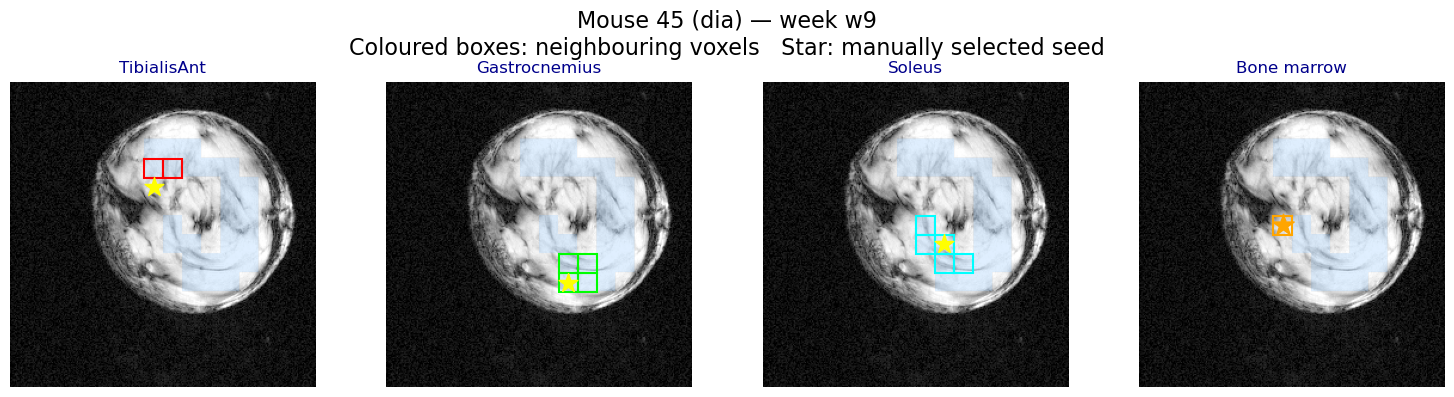

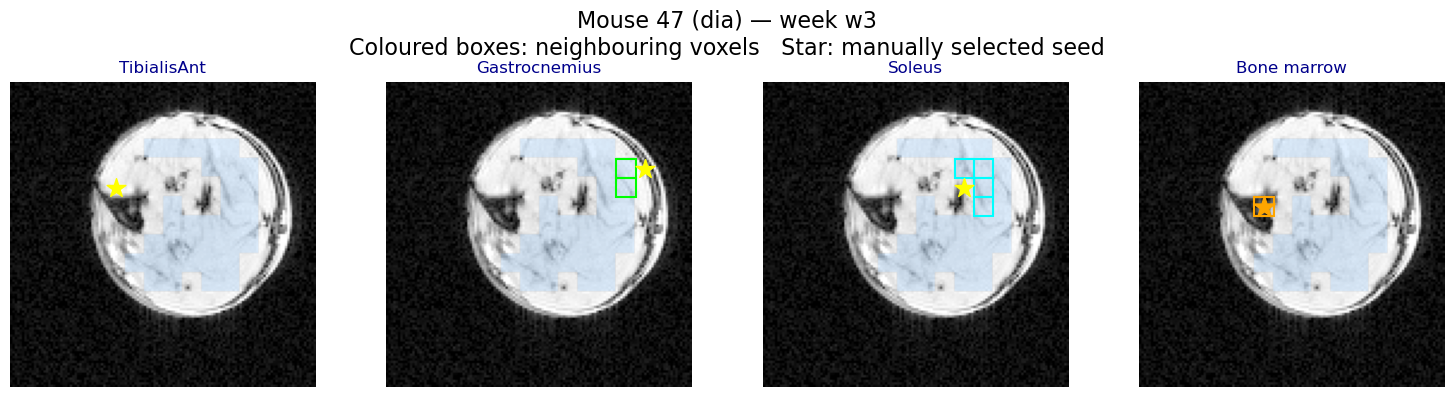

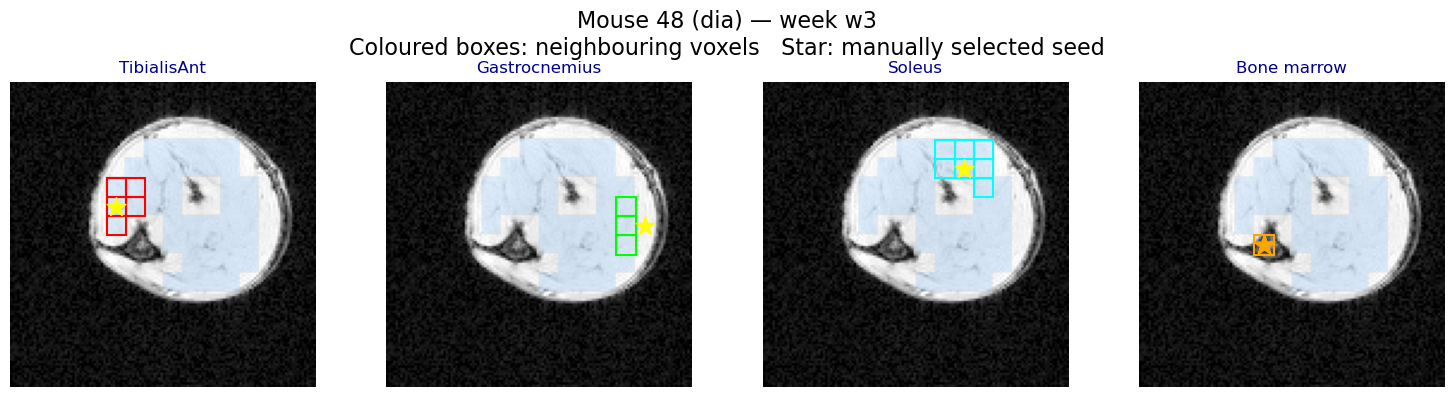

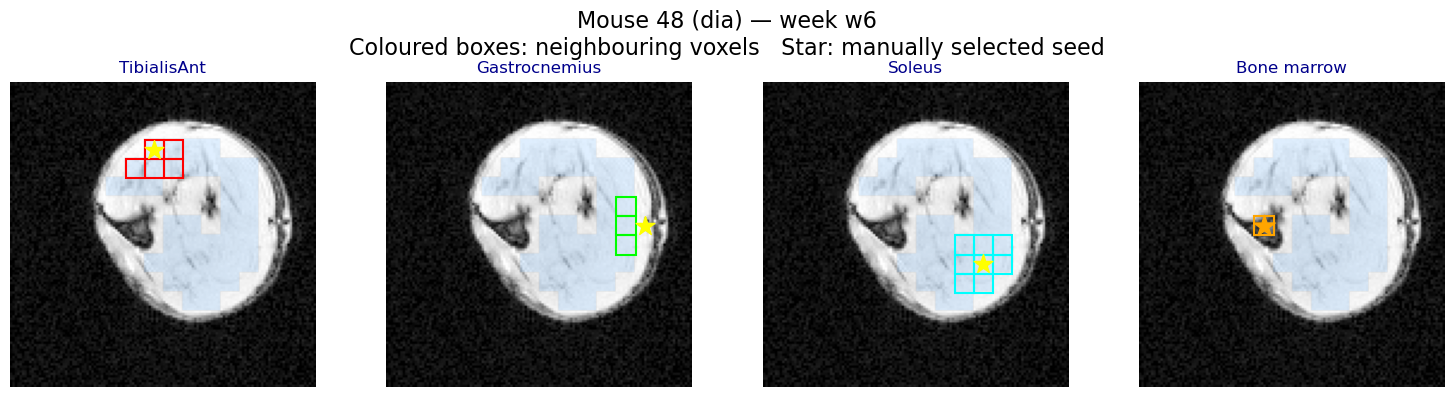

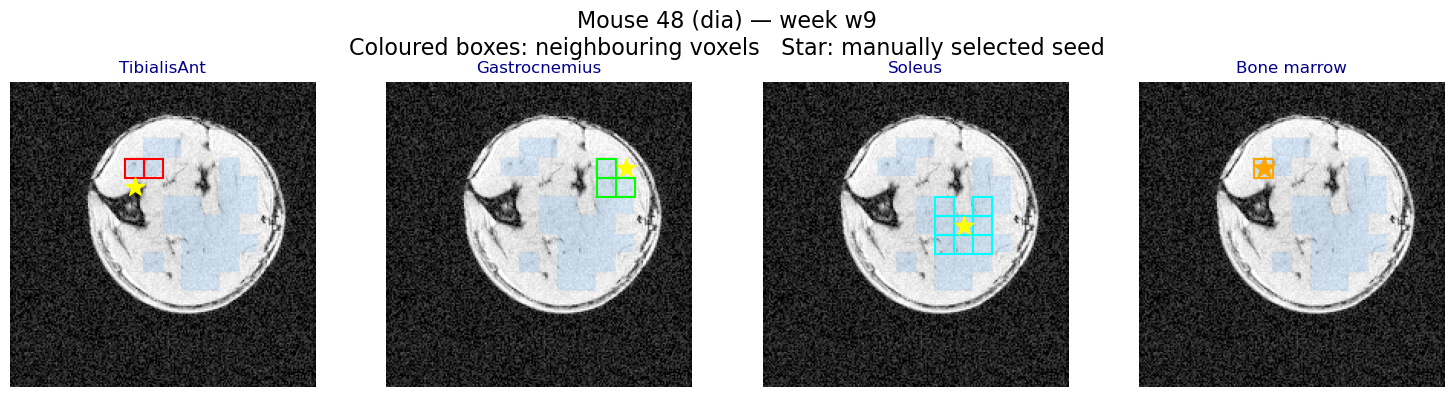

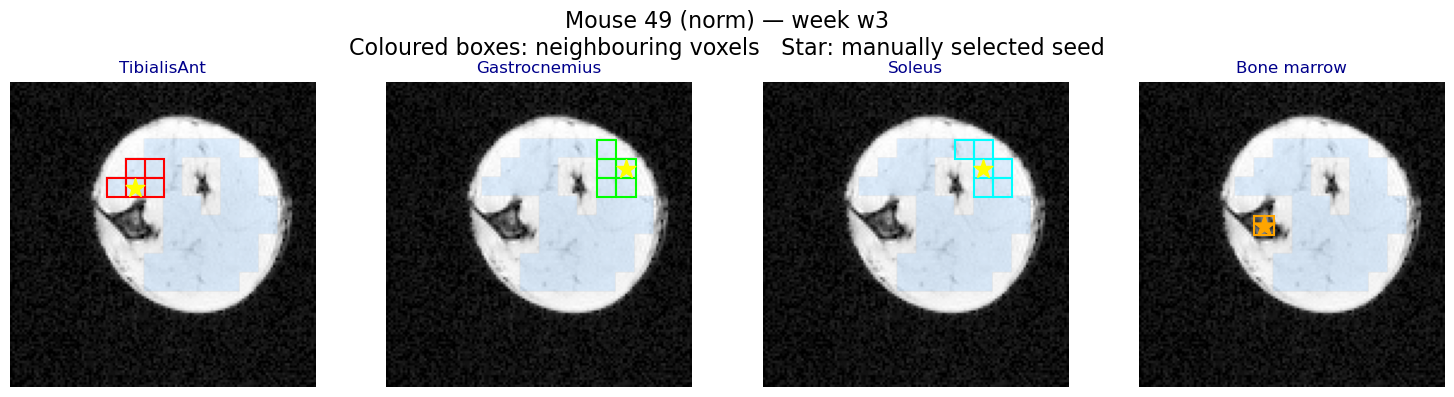

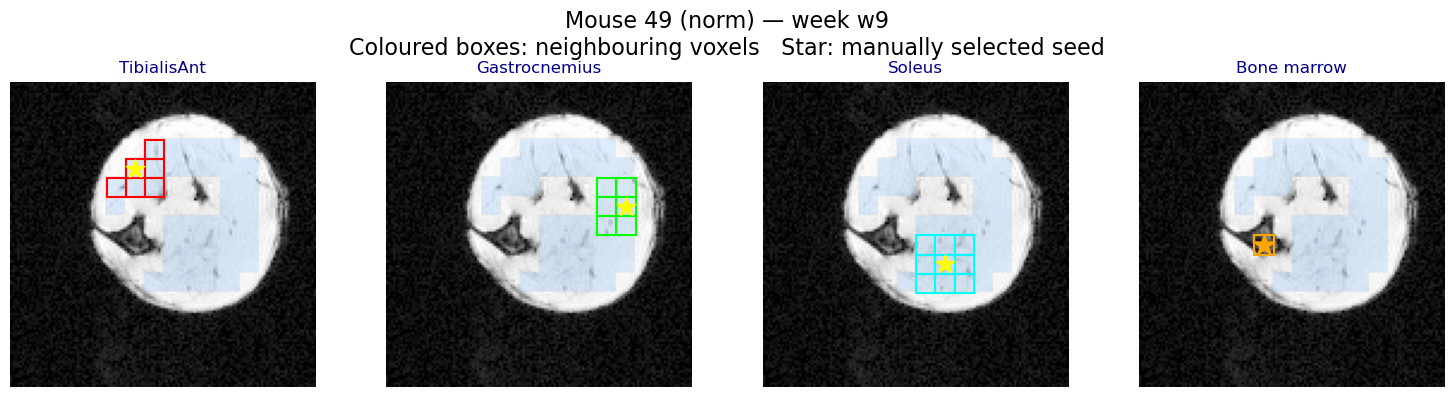

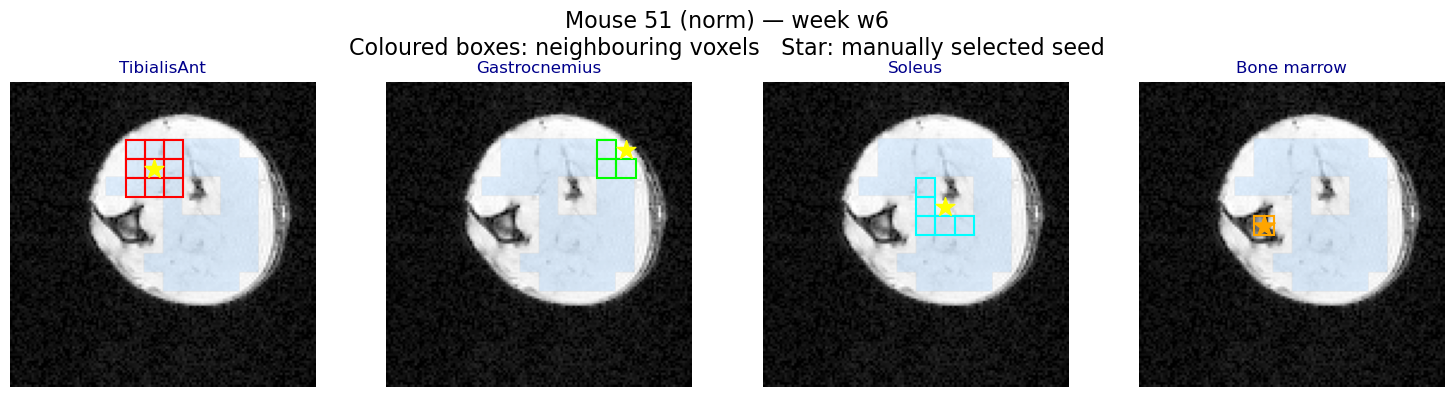

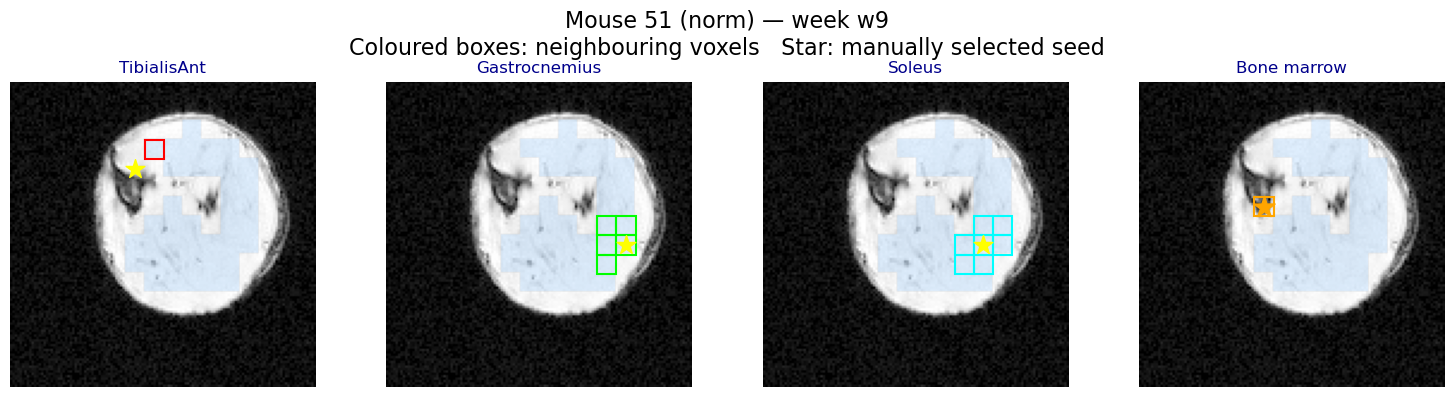

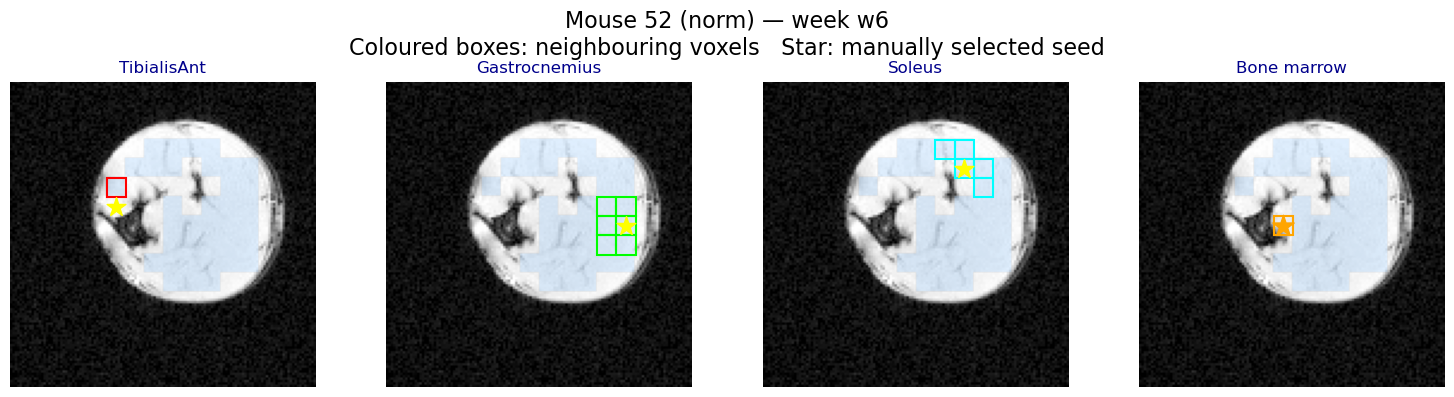

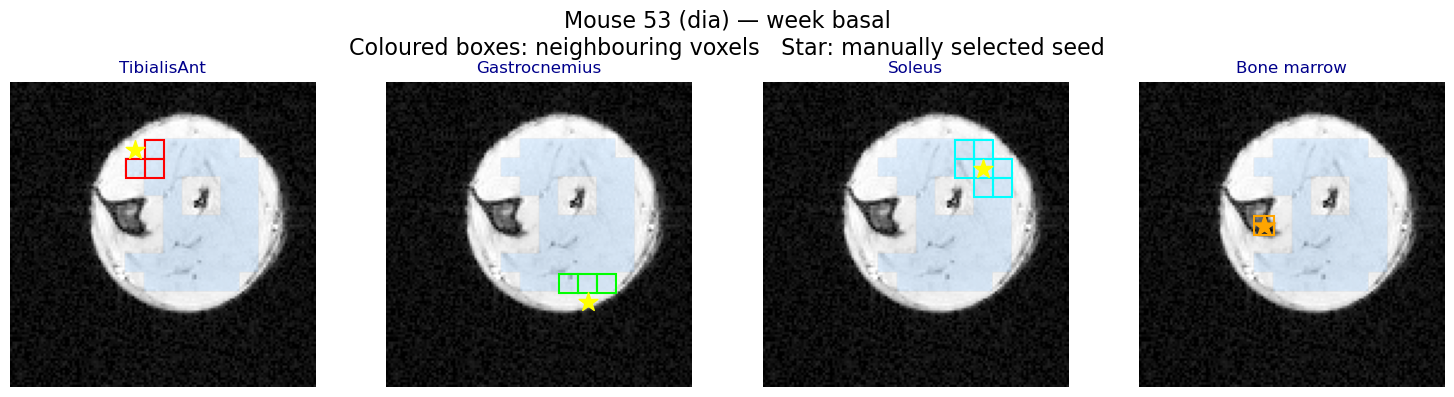

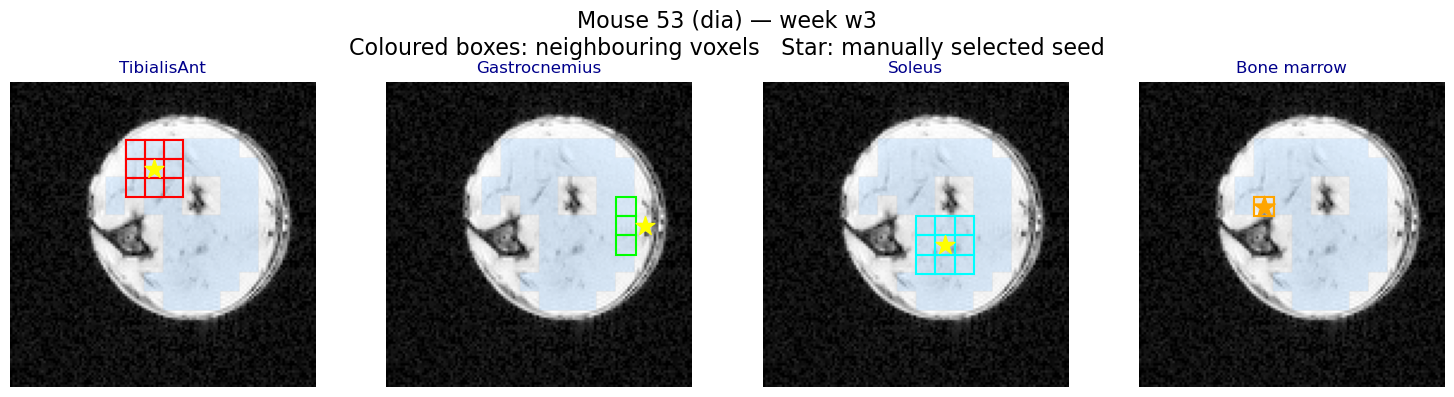

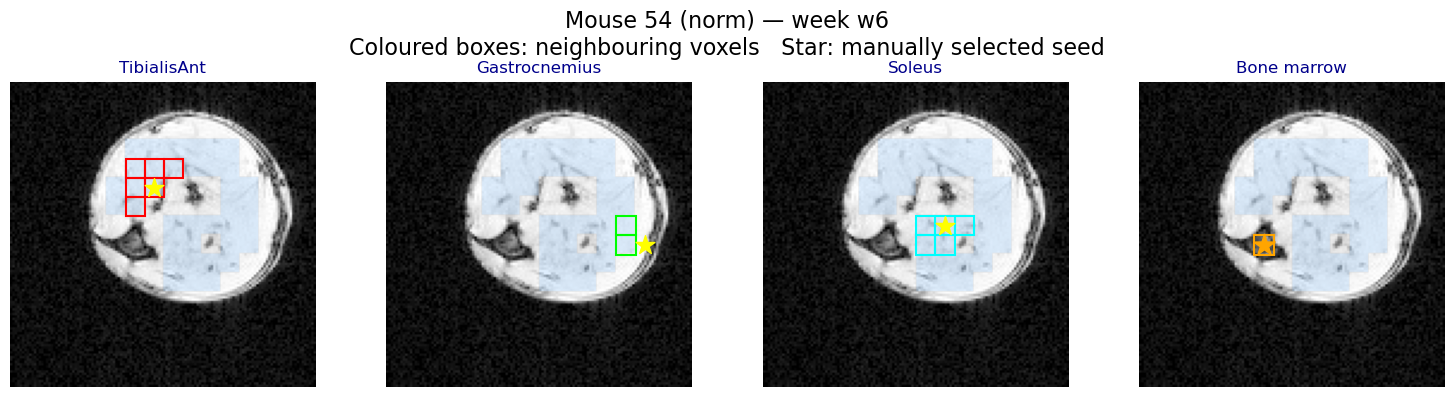

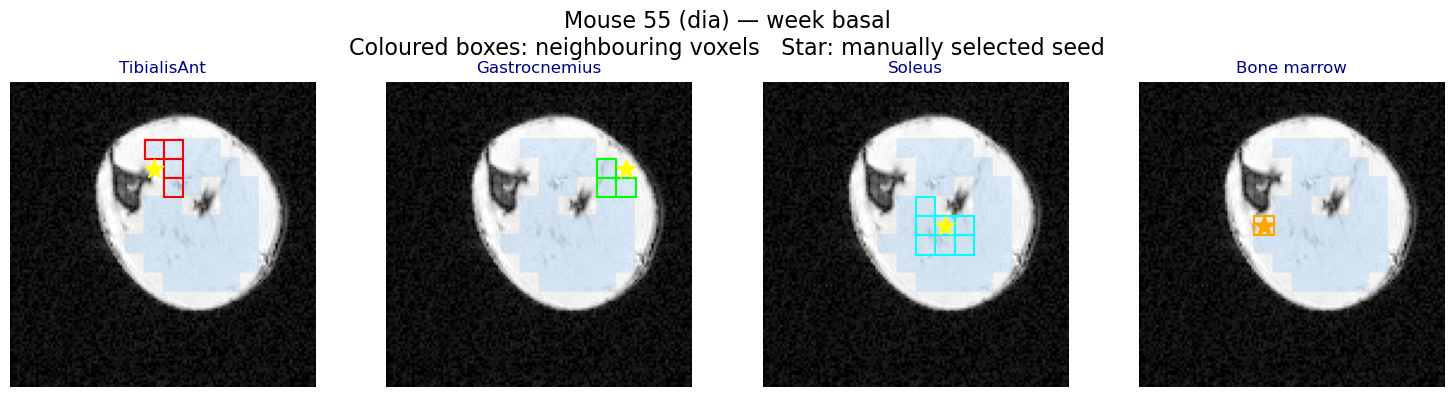

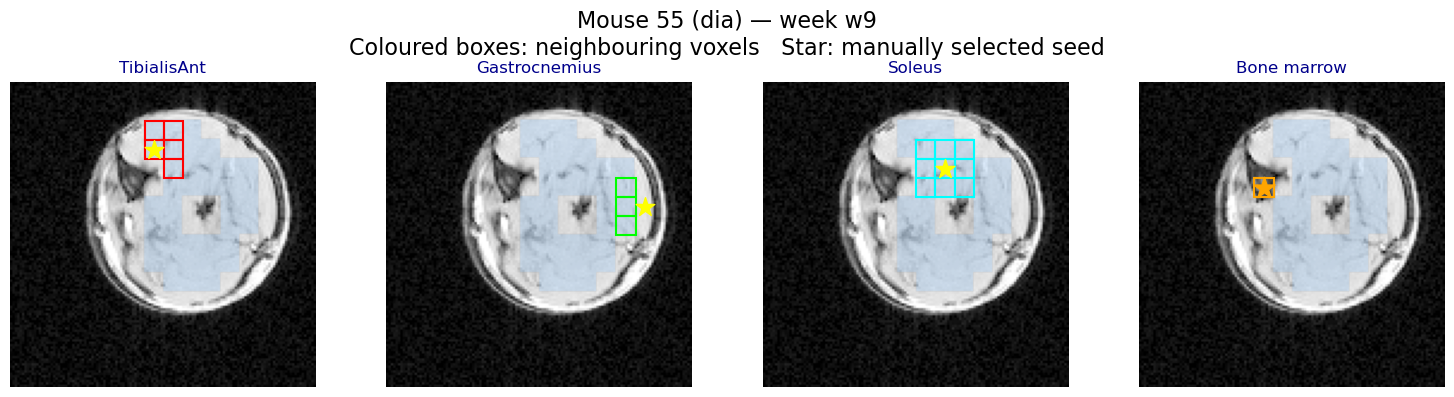

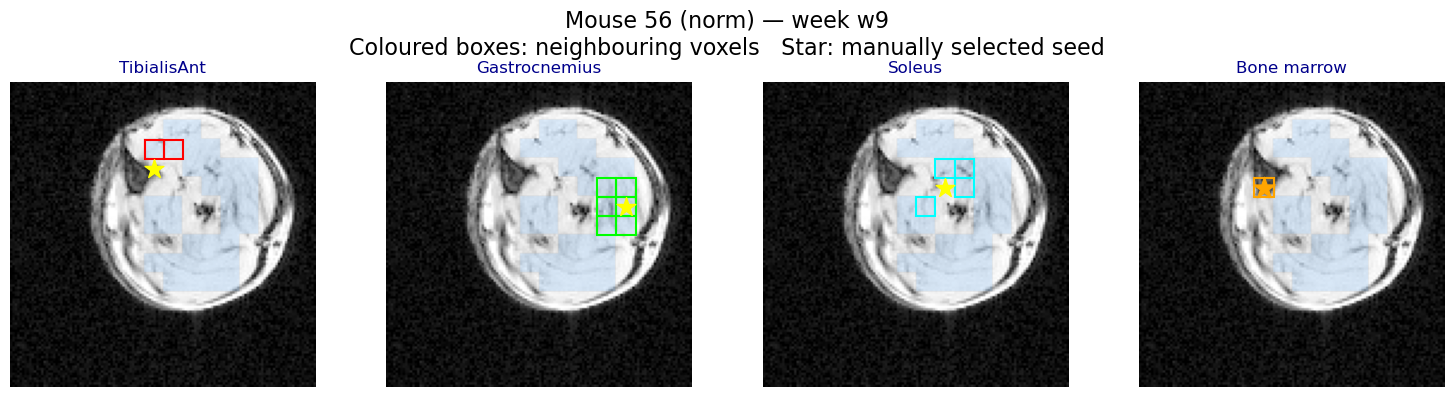

In [23]:
roi_masks_all = f_get_roi_masks()

# All tissues shown in the ROI overview (Knochenmark is reference-only, not fitted)
ALL_DISPLAY_TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus', 'Knochenmark']
TISSUE_EDGE_COLORS  = {
    'TibialisAnt':   'red',
    'Gastrocnemius': 'lime',
    'Soleus':        'cyan',
    'Knochenmark':   'orange',
}


def get_expanded_roi(tissue, week, mouseID, radius=ROI_RADIUS):
    """
    Return 0-based (row, col) voxel coordinates for the expanded ROI.

    Steps:
      1. Look up the manually annotated seed voxel in lib_roi_masks.
      2. Expand to all voxels within Chebyshev distance `radius`
         (radius=1 → up to 3×3 = 9 candidates).
      3. Intersect with the valid hindlimb mask (hash_mouseID2week2maskMap)
         so that only voxels inside the tissue segmentation are kept.

    Returns [] if the entry is missing or marked None (no valid ROI).
    """
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return []

    seed_rows, seed_cols = np.where(seed_mask)
    if len(seed_rows) == 0:
        return []
    r0, c0 = int(seed_rows[0]), int(seed_cols[0])

    # All voxels within Chebyshev ball of radius r
    candidates = [
        (r0 + dr, c0 + dc)
        for dr in range(-radius, radius + 1)
        for dc in range(-radius, radius + 1)
        if 0 <= r0 + dr < NX and 0 <= c0 + dc < NY
    ]

    tissue_mask = hash_mouseID2week2maskMap.get(mouseID, {}).get(week, None)
    if tissue_mask is None:
        return candidates
    return [(r, c) for r, c in candidates if tissue_mask[r, c]]


def get_seed_rc(tissue, week, mouseID):
    """Return (row, col) of the annotated seed voxel, or None."""
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return None
    rows, cols = np.where(seed_mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])


# ── ROI overview: one figure per (mouseID, week), 4 tissue columns ──────────
from skimage.transform import resize as sk_resize   # for mask upscaling

N_COL = len(ALL_DISPLAY_TISSUES)

for (mid, wk) in available_combos:
    anat = hash_mouseID2week2H1anatomical.get(mid, {}).get(wk, None)
    if anat is None:
        continue

    anat_h, anat_w = anat.shape
    scale_r = anat_h / NX
    scale_c = anat_w / NY

    grp  = hash_mouseID2group.get(mid, '?')
    fig, axes = plt.subplots(1, N_COL, figsize=(3.8 * N_COL, 4))

    for ax, tissue in zip(axes, ALL_DISPLAY_TISSUES):
        ax.imshow(anat, cmap='gray', origin='upper')

        # ── hindlimb mask (blue overlay) ──────────────────────────────────
        hmask = hash_mouseID2week2maskMap.get(mid, {}).get(wk, None)
        if hmask is not None:
            hmask_up = sk_resize(hmask.astype(float), (anat_h, anat_w), order=0)
            rgba = np.zeros((*hmask_up.shape, 4))
            rgba[hmask_up > 0.5] = [0.2, 0.6, 1.0, 0.15]
            ax.imshow(rgba, origin='upper')

        edge_col = TISSUE_EDGE_COLORS[tissue]

        if tissue == 'Knochenmark':
            # Bone marrow is shown as reference only (single seed point, no expansion)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c, (r + 0.5) * scale_r,
                    marker='*', s=260, c='orange', zorder=5
                )
                ax.add_patch(plt.Rectangle(
                    (c * scale_c, r * scale_r), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = '(ref, not fitted)'
        else:
            # Fitted tissues: show seed star + expanded ROI boxes
            roi_coords = get_expanded_roi(tissue, wk, mid)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c, (r + 0.5) * scale_r,
                    marker='*', s=200, c='yellow', zorder=5
                )
            for (r, c) in roi_coords:
                ax.add_patch(plt.Rectangle(
                    (c * scale_c, r * scale_r), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = f'{len(roi_coords)} voxels'

        # ax.set_title(f'{tissue}\n{n_vox_label}', fontsize=12, color=edge_col)
        ax.set_title(f'{tissue.replace("Knochenmark", "Bone marrow")}', fontsize=12, color='darkblue')
        ax.axis('off')

    # Legend (one per figure)
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
                   markersize=10, label='Seed voxel (fitted tissues)'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='orange',
                   markersize=10, label='Bone marrow (reference)'),
    ]
    for tis, col in TISSUE_EDGE_COLORS.items():
        legend_elements.append(
            Patch(edgecolor=col, facecolor='none', linewidth=2, label=tis)
        )
    # axes[-1].legend(handles=legend_elements, fontsize=6.5,
    #                 loc='lower right', framealpha=0.7)

    fig.suptitle(
        f'Mouse {mid} ({grp}) — week {wk}\n'
        f'Coloured boxes: neighbouring voxels   Star: manually selected seed',
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

# # Summary table
# print('\nROI voxel counts (radius=1):')
# for mid, wk in available_combos:
#     for tissue in TISSUES:
#         coords = get_expanded_roi(tissue, wk, mid)
#         if coords:
#             print(f'  Mouse {mid} {wk} {tissue}: {len(coords)} voxels')


In [6]:
# MRI metabolite name → model variable key
MET_MAP = {'Glucose': 'glc', 'Glutamate': 'glx', 'Lactate': 'lac'}


def extract_voxel_timeseries(mouseID, week, roi_coords):
    """
    Extract post-injection labelled metabolite time-series at each ROI voxel.

    The injection is taken to occur at t = 0 (the first post-injection scan).
    All time-series therefore start at zero label and rise with subsequent scans,
    matching the model assumption that all state variables are zero at t = 0.

    Returns
    -------
    voxel_data : list of dicts, one per valid voxel
        keys: 'coords', 'time_min', 'glc', 'lac', 'glx'
    """
    sub = df_image_data[
        (df_image_data['mouseID'] == mouseID) &
        (df_image_data['week']   == week)
    ].copy()
    if sub.empty:
        return []

    sub_post = sub[sub['time'] >= 0].copy()

    voxel_data = []
    for (row, col) in roi_coords:
        vox = {'coords': (row, col)}
        valid = True
        time_ref = None

        for mri_name, key in MET_MAP.items():
            met_rows = sub_post[sub_post['mname'] == mri_name].sort_values('time')
            if met_rows.empty:
                valid = False
                break

            time_min = met_rows['time'].values.astype(float) / 60.0
            if time_ref is None:
                time_ref = time_min
            elif not np.allclose(time_min, time_ref):
                print(f'WARNING: time-grid mismatch for Mouse {mouseID} {week} voxel {(row, col)}; skipping voxel')
                valid = False
                break

            imgs     = np.stack(met_rows['cur_image'].values)   # (n_scans, 16, 16)
            vox[key] = imgs[:, row, col].astype(float)          # (n_scans,)

        if not valid:
            continue

        vox['time_min'] = time_ref

        # Discard voxels where the Glc* signal never exceeds the noise floor
        if np.max(np.abs(vox['glc'])) < MIN_SIGNAL_MM:
            continue

        voxel_data.append(vox)

    return voxel_data


# Quick sanity print
test_tissue = 'TibialisAnt'
test_mid, test_wk = 53, 'basal'
test_coords = get_expanded_roi(test_tissue, test_wk, test_mid)
test_data = extract_voxel_timeseries(test_mid, test_wk, test_coords)
print(f'Test: Mouse {test_mid} {test_wk} {test_tissue}')
print(f'  ROI voxels: {test_coords}')
print(f'  Valid after quality filter: {len(test_data)}')
if test_data:
    v0 = test_data[0]
    print(f'  Voxel {v0["coords"]}:')
    print(f'    time [min]: {np.round(v0["time_min"], 1)}')
    print(f'    Glc* [mM]:  {np.round(v0["glc"], 2)}')
    print(f'    Lac* [mM]:  {np.round(v0["lac"], 2)}')
    print(f'    Glx* [mM]:  {np.round(v0["glx"], 2)}')


Test: Mouse 53 basal TibialisAnt
  ROI voxels: [(3, 7), (4, 6), (4, 7)]
  Valid after quality filter: 3
  Voxel (3, 7):
    time [min]: [ 0.   4.7  9.3 14.  18.7 23.3 28.  32.7 37.3 42.  46.7]
    Glc* [mM]:  [-0.92 -1.06  1.05  2.77  3.19  4.81  3.49  4.95  5.36  6.    4.78]
    Lac* [mM]:  [-0.13  0.09  0.05 -0.27  0.08  0.24  0.54  0.21  0.83  0.37  0.18]
    Glx* [mM]:  [1.59 3.79 5.59 2.8  2.81 7.13 3.58 2.6  6.38 5.56 9.2 ]


In [7]:
def compute_v_lk(MR_glc, V_out):
    """Deterministic forward Lac/Pyr -> K flux implied by the model topology."""
    return 2 * MR_glc - V_out


def plasma_input(t_min, fp):
    """Fixed exponential surrogate plasma input after IV bolus."""
    return fp['a1'] * np.exp(-fp['kp'] * t_min) if t_min >= 0 else 0.0


def ode_rhs(y, t, T_max, V_x, MR_glc, V_TCA, V_out, fp):
    """Right-hand side of the 4-compartment DMI model with deterministic V_LK."""
    Glc_star, L_star, K_star, Glx_star = y

    # Glc_star = max(min(Glc_star, fp['Glc_cell']), 0.0)
    # L_star   = max(min(L_star,   fp['L']),        0.0)
    # K_star   = max(min(K_star,   fp['K']),        0.0)
    # Glx_star = max(min(Glx_star, fp['Glx']),      0.0)

    Glc_star = abs(Glc_star)
    L_star   = abs(L_star)
    K_star   = abs(K_star)
    Glx_star = abs(Glx_star)

    Glc_p_star = plasma_input(t, fp)

    Glc_c = fp['Glc_cell']
    Glc_p = fp['Glc_p_total']
    L, K, Glx = fp['L'], fp['K'], fp['Glx']
    f_gly, f_tca = fp['f_gly'], fp['f_tca']
    KT = fp['KT']

    kie_gly = fp.get('kie_gly', 1.0)
    kie_tca = fp.get('kie_tca', 1.0)
    MR_glc_iso = MR_glc / kie_gly
    V_LK       = compute_v_lk(MR_glc, V_out)
    V_LK_iso   = V_LK / kie_tca

    dGlc_star = (
          T_max * Glc_p_star / (KT + Glc_p + Glc_p_star)
        - T_max * Glc_star   / (KT + Glc_c + Glc_star)
        - MR_glc_iso * Glc_star / (Glc_c + Glc_star)
    )

    dL_star = (
          (1 - f_gly) * 2 * MR_glc_iso * Glc_star / (Glc_c + Glc_star)
        - (V_out + V_LK_iso) * L_star / (L + L_star)
    )

    dK_star = (
          (1 - f_tca) * V_LK_iso * L_star / (L + L_star)
        - (V_x + V_TCA) * K_star / (K + K_star)
        + V_x * Glx_star / (Glx + Glx_star)
    )

    dGlx_star = V_x * (K_star / (K + K_star) - Glx_star / (Glx + Glx_star))
    return [dGlc_star, dL_star, dK_star, dGlx_star]


def simulate_voxel(t_eval_min, T_max, V_x, MR_glc, V_TCA, V_out, fp):
    """Integrate the deterministic-V_LK ODE model with fixed plasma input."""
    y0 = [0.0, 0.0, 0.0, 0.0]

    try:
        sol = odeint(
            ode_rhs, y0, t_eval_min,
            args=(T_max, V_x, MR_glc, V_TCA, V_out, fp),
            rtol=1e-5, atol=1e-7, mxstep=5000,
        )
    except Exception:
        return None

    sol[:, 0] = np.clip(sol[:, 0], 0.0, fp['Glc_cell'])
    sol[:, 1] = np.clip(sol[:, 1], 0.0, fp['L'])
    sol[:, 2] = np.clip(sol[:, 2], 0.0, fp['K'])
    sol[:, 3] = np.clip(sol[:, 3], 0.0, fp['Glx'])

    Glc_cell_star = sol[:, 0]
    L_star        = sol[:, 1]
    Glx_star      = sol[:, 3]
    fv = fp['fv']
    Glc_p_star_t = np.array([plasma_input(ti, fp) for ti in t_eval_min])
    glc_pred = (1 - fv) * Glc_cell_star + fv * Glc_p_star_t

    return {'glc': glc_pred, 'lac': L_star, 'glx': Glx_star}


_fp_test = dict(FIXED_PARAMS)
_t = np.linspace(0, 47, 100)
_pred = simulate_voxel(_t, T_max=1.5, V_x=2.0, MR_glc=0.15, V_TCA=0.20, V_out=0.05, fp=_fp_test)
print(f"Fixed plasma input: a1={FIXED_PARAMS['a1']:.1f} mM, kp={FIXED_PARAMS['kp']:.3f} min^-1")
print(f'Derived V_LK = {compute_v_lk(0.15, 0.05):.3f} mM/min')
if _pred is not None:
    print(f'At t=0: Glc*={_pred["glc"][0]:.4f}  Lac*={_pred["lac"][0]:.4f}  Glx*={_pred["glx"][0]:.4f}')
    print(f'Peak:   Glc*={_pred["glc"].max():.2f} mM  Lac*={_pred["lac"].max():.3f} mM  Glx*={_pred["glx"].max():.2f} mM')


Fixed plasma input: a1=35.0 mM, kp=0.020 min^-1
Derived V_LK = 0.250 mM/min


In [8]:
def joint_objective(theta, voxel_data_list, fixed_base, n_shared=3):
    """Variance-normalized objective with fixed plasma input and deterministic V_LK.
    Shared params: theta[0]=T_max, theta[1]=V_x, theta[2]=KT (fitted, shared across voxels).
    Per-voxel params start at theta[3 + 3*i].
    """
    T_max, V_x, KT = theta[0], theta[1], theta[2]
    fp = {**fixed_base, 'KT': KT}   # override fixed KT with the fitted value
    total_cost = 0.0

    for i, vox in enumerate(voxel_data_list):
        MR_glc = theta[n_shared + 3 * i]
        V_TCA  = theta[n_shared + 3 * i + 1]
        V_out  = theta[n_shared + 3 * i + 2]
        V_LK   = compute_v_lk(MR_glc, V_out)

        if V_LK < 0:
            return 1e12

        pred = simulate_voxel(vox['time_min'], T_max, V_x, MR_glc, V_TCA, V_out, fp)
        if pred is None:
            return 1e12

        for key in ('glc', 'lac', 'glx'):
            resid = vox[key] - pred[key]
            var_floor = max(np.var(vox[key]), 0.01)
            total_cost += np.sum(resid ** 2) / var_floor

    return total_cost


def build_bounds(n_voxels):
    return BOUNDS_SHARED + BOUNDS_PER_VOX * n_voxels


def build_x0(tissue, n_voxels):
    init = TISSUE_INIT.get(tissue, TISSUE_INIT['Gastrocnemius'])
    return np.array(
        [init['T_max'], init['V_x'], init['KT']]
        + [init['MR_glc'], init['V_TCA'], init['V_out']] * n_voxels
    )


def fit_sample(mouseID, week, tissue, radius=ROI_RADIUS, verbose=True):
    roi_coords = get_expanded_roi(tissue, week, mouseID, radius=radius)
    if not roi_coords:
        return None

    voxel_data = extract_voxel_timeseries(mouseID, week, roi_coords)
    if not voxel_data:
        return None

    N = len(voxel_data)
    bounds = build_bounds(N)
    fixed_base = dict(FIXED_PARAMS)

    if verbose:
        grp = hash_mouseID2group.get(mouseID, '?')
        print(f'  Fitting Mouse {mouseID} ({grp}) | {week} | {tissue} | {N} voxels ...', end='', flush=True)

    de_result = differential_evolution(
        joint_objective,
        bounds=bounds,
        args=(voxel_data, fixed_base),
        maxiter=150,
        popsize=8,
        tol=1e-5,
        seed=42,
        workers=1,
        polish=False,
        init='latinhypercube',
    )

    lbfgs_result = minimize(
        joint_objective,
        x0=de_result.x,
        args=(voxel_data, fixed_base),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 500, 'ftol': 1e-10, 'gtol': 1e-8},
    )

    theta = lbfgs_result.x
    T_max, V_x, KT = theta[0], theta[1], theta[2]
    fp_final = {**FIXED_PARAMS, 'KT': KT}   # use fitted KT for final predictions

    vox_results = []
    for i, vox in enumerate(voxel_data):
        MR_glc = theta[3 + 3 * i]
        V_TCA  = theta[3 + 3 * i + 1]
        V_out  = theta[3 + 3 * i + 2]
        V_LK   = compute_v_lk(MR_glc, V_out)

        pred = simulate_voxel(vox['time_min'], T_max, V_x, MR_glc, V_TCA, V_out, fp_final)

        r2 = {}
        for key in ('glc', 'lac', 'glx'):
            obs = vox[key]
            model = pred[key] if pred is not None else np.zeros_like(obs)
            ss_res = np.sum((obs - model) ** 2)
            ss_tot = np.sum((obs - obs.mean()) ** 2)
            r2[key] = 1 - ss_res / (ss_tot + 1e-12)

        vox_results.append(dict(
            coords=vox['coords'],
            MR_glc=MR_glc,
            V_TCA=V_TCA,
            V_out=V_out,
            V_LK=V_LK,
            r2_glc=r2['glc'],
            r2_lac=r2['lac'],
            r2_glx=r2['glx'],
            r2_mean=(r2['glc'] + r2['lac'] + r2['glx']) / 3,
            voxel_data=vox,
            pred=pred,
        ))

    if verbose:
        mean_r2 = np.mean([v['r2_mean'] for v in vox_results])
        print(f'  done.  mean R²={mean_r2:.3f}  cost={lbfgs_result.fun:.2f}  KT={KT:.2f} mM')

    return dict(
        model_version='deterministic_vlk_fixed_input_v1',
        mouseID=mouseID,
        week=week,
        tissue=tissue,
        group=hash_mouseID2group.get(mouseID, 'unknown'),
        T_max=T_max,
        V_x=V_x,
        KT=KT,
        a1=FIXED_PARAMS['a1'],
        kp=FIXED_PARAMS['kp'],
        voxels=vox_results,
        final_cost=lbfgs_result.fun,
        success=lbfgs_result.success,
    )


# print('Quick test — Mouse 53 basal TibialisAnt:')
# test_result = fit_sample(53, 'basal', 'TibialisAnt', verbose=True)
# if test_result:
#     print(
#         f"  T_max={test_result['T_max']:.3f}  V_x={test_result['V_x']:.3f}  "
#         f"KT={test_result['KT']:.3f} mM  a1={test_result['a1']:.1f} fixed  kp={test_result['kp']:.4f} fixed"
#     )
#     for vr in test_result['voxels']:
#         print(
#             f'  Voxel {vr["coords"]}: MR_glc={vr["MR_glc"]:.4f}  V_TCA={vr["V_TCA"]:.4f}  '
#             f'V_out={vr["V_out"]:.4f}  V_LK={vr["V_LK"]:.4f}  '
#             f'R²(Glc/Lac/Glx)={vr["r2_glc"]:.2f}/{vr["r2_lac"]:.2f}/{vr["r2_glx"]:.2f}'
#         )
# else:
#     print('  No valid voxels found.')


In [10]:
# Cell 7 — Run All Fits (parallel)
#
# Estimated runtime (single machine, 8 CPU cores):
#   ~2–6 min per (mouse, week, tissue) with DE maxiter=150, popsize=8
#   ~17 combos × 3 tissues = 51 cases → ~1.7–5.1 hours total
# Each (mouseID, week, tissue) case is dispatched to a separate worker process.
# Results are saved after each case completes so partial progress is recoverable.

import os
from concurrent.futures import ProcessPoolExecutor, as_completed

results_path = DATA_DIR / RESULTS_FILENAME

# # Load existing results if present (allows resuming)
# if results_path.exists():
#     all_results = joblib.load(results_path)
#     print(f'Loaded {len(all_results)} existing results from {results_path}')
# else:
#     all_results = []

all_results = []

# Build set of already completed (mouseID, week, tissue) keys
done_keys = {(r['mouseID'], r['week'], r['tissue']) for r in all_results}

# # Build list of remaining tasks
# tasks = [
#     (mid, wk, tissue)
#     for (mid, wk) in available_combos
#     for tissue in TISSUES
#     if (mid, wk, tissue) not in done_keys
# ]

# for testing, run only a subset of tasks (e.g., just TibialisAnt)
tasks = [(53, 'w3', 'TibialisAnt')]
    

n_workers = os.cpu_count() or 4
skipped   = len(done_keys)
total     = skipped + len(tasks)

for mid, wk, tissue in [(r['mouseID'], r['week'], r['tissue']) for r in all_results]:
    print(f'Skipping Mouse {mid} {wk} {tissue} (already done)')

print(f'\n{skipped} already done, {len(tasks)} remaining — using {n_workers} workers.')

if tasks:
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        future_to_key = {
            executor.submit(fit_sample, mid, wk, tissue, ROI_RADIUS, False): (mid, wk, tissue)
            for mid, wk, tissue in tasks
        }
        for future in as_completed(future_to_key):
            mid, wk, tissue = future_to_key[future]
            try:
                result = future.result()
            except Exception as exc:
                print(f'  ERROR Mouse {mid} {wk} {tissue}: {exc}')
                result = None
            if result is not None:
                all_results.append(result)
                done_keys.add((mid, wk, tissue))
            # Save after each completed case to allow recovery
            joblib.dump(all_results, results_path, compress=('xz', 3))
            print(f'  [{len(done_keys)}/{total}] saved  Mouse {mid} {wk} {tissue}')

print(f'\nAll fits completed. {len(all_results)} results saved to {results_path}')



0 already done, 1 remaining — using 14 workers.
  [1/1] saved  Mouse 53 w3 TibialisAnt

All fits completed. 1 results saved to /home/pty/work/project_MRI/extract_MRI_metabolite_concentration/fit_results_MRI_fluxes_vlk_fixed_input.joblib.xz


In [11]:
all_results

[{'model_version': 'deterministic_vlk_fixed_input_v1',
  'mouseID': 53,
  'week': 'w3',
  'tissue': 'TibialisAnt',
  'group': 'dia',
  'T_max': np.float64(0.35706192901714456),
  'V_x': np.float64(8.408215444767631),
  'KT': np.float64(5.103503266799274),
  'a1': 35.0,
  'kp': 0.02,
  'voxels': [{'coords': (3, 6),
    'MR_glc': np.float64(0.6050708328544732),
    'V_TCA': np.float64(0.6238169735237585),
    'V_out': np.float64(0.0),
    'V_LK': np.float64(1.2101416657089463),
    'r2_glc': np.float64(0.11815924013420953),
    'r2_lac': np.float64(-2.3935259316837842),
    'r2_glx': np.float64(0.35939398166528813),
    'r2_mean': np.float64(-0.638657569961429),
    'voxel_data': {'coords': (3, 6),
     'glc': array([0.54222692, 0.89999215, 1.85502972, 2.34923959, 2.13950728,
            3.66115859, 2.80662863, 3.46011402, 3.89800965, 3.68396484,
            3.32968292, 4.80432755, 4.66503195]),
     'glx': array([-1.24994985, -1.75775265,  2.60533569,  0.18723035,  2.14353078,
         

Plotting 1 time-course fits...


/tmp/ipykernel_3713457/422483153.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', max(n_vox, 1))


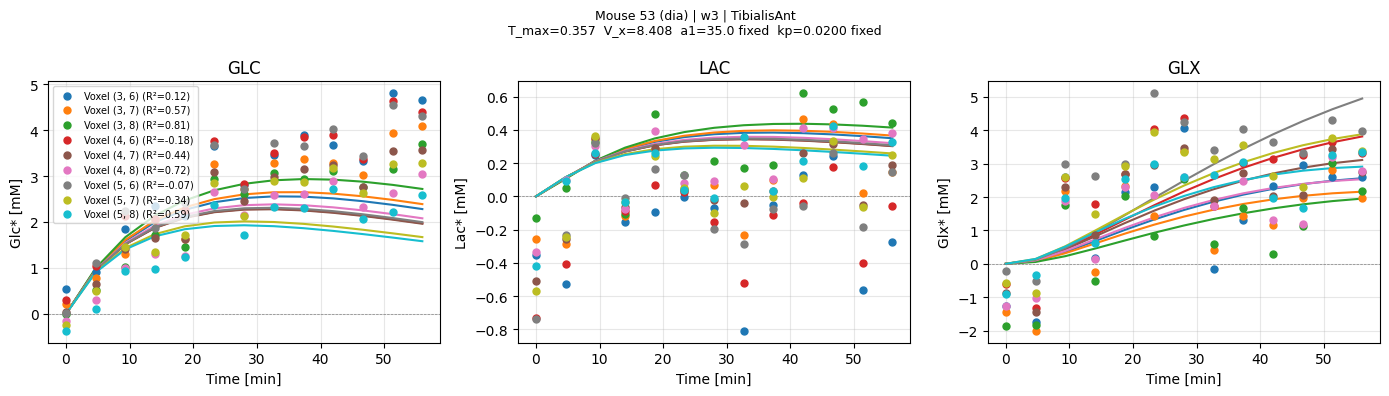

Time-course plots saved to /home/pty/work/project_MRI/extract_MRI_metabolite_concentration/plots/


In [ ]:
# Cell 8 — Plotting: Time-Course Overlay
#
# For each fitted (mouseID, week, tissue):
#   3-column subplot: Glc*, Lac*, Glx*
#   One line per voxel: data=markers, model=solid line
#   Colour-coded by voxel index within ROI

results_path = DATA_DIR / RESULTS_FILENAME
try:
    all_results
except NameError:
    if results_path.exists():
        all_results = joblib.load(results_path)
    elif 'test_result' in globals() and test_result:
        all_results = [test_result]
        print('Using test_result for plotting because no saved results file exists yet.')
    else:
        raise FileNotFoundError(f'No results file found at {results_path}. Run Cell 7 first.')

MET_LABELS = {'glc': 'Glc* [mM]', 'lac': 'Lac* [mM]', 'glx': 'Glx* [mM]'}
MET_COLORS = {'glc': 'tab:blue', 'lac': 'tab:orange', 'glx': 'tab:green'}

plots_dir = DATA_DIR / 'plots_vlk_deterministic'
plots_dir.mkdir(exist_ok=True)


def infer_vlk(vr):
    if 'V_LK' in vr:
        return vr['V_LK']
    return 2 * vr['MR_glc'] - vr['V_out']


def get_fixed_a1(result=None):
    return FIXED_PARAMS['a1']


def get_fixed_kp(result=None):
    return FIXED_PARAMS['kp']


def get_voxel_param(vr, param):
    if param == 'V_LK':
        return infer_vlk(vr)
    return vr[param]


def plot_timecourse(result, save_dir=plots_dir, show=False):
    mid     = result['mouseID']
    wk      = result['week']
    tissue  = result['tissue']
    grp     = result['group']
    T_max   = result['T_max']
    V_x     = result['V_x']
    a1      = get_fixed_a1(result)
    kp      = get_fixed_kp(result)
    voxels  = result['voxels']

    n_vox = len(voxels)
    if n_vox == 0:
        return

    cmap = cm.get_cmap('tab10', max(n_vox, 1))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    keys = ('glc', 'lac', 'glx')

    for ax, key in zip(axes, keys):
        for j, vr in enumerate(voxels):
            color = cmap(j)
            t   = vr['voxel_data']['time_min']
            obs = vr['voxel_data'][key]
            ax.scatter(t, obs, color=color, s=25, zorder=3,
                       label=f'Voxel {vr["coords"]} (R²={vr["r2_" + key]:.2f})')
            if vr['pred'] is not None:
                ax.plot(t, vr['pred'][key], color=color, linewidth=1.5,
                        linestyle='-', zorder=2)

        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        ax.set_xlabel('Time [min]')
        ax.set_ylabel(MET_LABELS[key])
        ax.set_title(key.upper())
        ax.grid(True, alpha=0.3)
        if key == 'glc':
            ax.legend(fontsize=7, loc='upper left')

    fig.suptitle(
        f'Mouse {mid} ({grp}) | {wk} | {tissue}\n'
        f'T_max={T_max:.3f}  V_x={V_x:.3f}  a1={a1:.1f} fixed  kp={kp:.4f} fixed',
        fontsize=9
    )
    plt.tight_layout()

    fname = save_dir / f'tc_mouse{mid}_{wk}_{tissue}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


print(f'Plotting {len(all_results)} time-course fits...')
for res in all_results:
    plot_timecourse(res, save_dir=plots_dir, show=True)
print(f'Time-course plots saved to {plots_dir}/')

# if test_result:
#     plot_timecourse(test_result, save_dir=plots_dir, show=True)


In [ ]:
# Cell 9 — Plotting: Parameter Maps
#
# For each (mouseID, week) that has results for ≥1 tissue:
#   Anatomical image (background) with scatter dots at ROI voxel positions.
#   Colour encodes the selected fitted parameter; marker size encodes mean R² quality.

PARAM_CMAP = 'plasma'


def plot_parameter_map(mouseID, week, results_list, param='MR_glc',
                        save_dir=plots_dir, show=False):
    """
    Overlay fitted parameter values on the anatomical image.

    Parameters
    ----------
    param : one of 'MR_glc', 'V_TCA', 'V_out', 'V_LK'
    """
    anat = hash_mouseID2week2H1anatomical.get(mouseID, {}).get(week, None)
    if anat is None:
        return

    anat_h, anat_w = anat.shape
    scale_r = anat_h / NX
    scale_c = anat_w / NY

    # Collect all values for colour normalisation
    all_vals = [
        get_voxel_param(vr, param)
        for res in results_list
        for vr in res['voxels']
    ]
    if not all_vals:
        return

    vmin, vmax = np.percentile(all_vals, 5), np.percentile(all_vals, 95)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_fn = cm.get_cmap(PARAM_CMAP)

    tissue_colors = {'TibialisAnt': 'red', 'Gastrocnemius': 'lime', 'Soleus': 'cyan'}

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(anat, cmap='gray', origin='upper')

    for res in results_list:
        tissue = res['tissue']
        for vr in res['voxels']:
            r, c = vr['coords']
            cx = (c + 0.5) * scale_c
            cy = (r + 0.5) * scale_r
            val = get_voxel_param(vr, param)
            r2  = max(vr['r2_mean'], 0.0)
            color = cmap_fn(norm(val))
            size  = 30 + 120 * r2  # marker size proportional to fit quality
            ax.scatter(cx, cy, s=size, c=[color], zorder=4,
                       edgecolors=tissue_colors.get(tissue, 'white'),
                       linewidths=1.5)

    # Colourbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap_fn)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=f'{param} [mM/min]', fraction=0.03, pad=0.02)

    # Legend for tissue colour
    legend_patches = [
        Patch(edgecolor=c, facecolor='none', linewidth=2, label=t)
        for t, c in tissue_colors.items()
        if any(res['tissue'] == t for res in results_list)
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right')

    grp = hash_mouseID2group.get(mouseID, '?')
    ax.set_title(f'Mouse {mouseID} ({grp}) | {week} | {param}\n'
                 f'Dot size ∝ mean R²  |  Edge colour = tissue', fontsize=9)
    ax.axis('off')
    plt.tight_layout()

    fname = save_dir / f'pmap_mouse{mouseID}_{week}_{param}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


# Group results by (mouseID, week)
from collections import defaultdict
res_by_mouse_week = defaultdict(list)
for res in all_results:
    res_by_mouse_week[(res['mouseID'], res['week'])].append(res)

print('Plotting parameter maps...')
for (mid, wk), res_list in sorted(res_by_mouse_week.items()):
    for param in ('MR_glc', 'V_TCA', 'V_out', 'V_LK'):
        plot_parameter_map(mid, wk, res_list, param=param,
                            save_dir=plots_dir, show=False)

print(f'Parameter maps saved to {plots_dir}/')

# Show one example
if (53, 'basal') in res_by_mouse_week:
    plot_parameter_map(53, 'basal', res_by_mouse_week[(53, 'basal')],
                        param='MR_glc', save_dir=plots_dir, show=True)


Plotting parameter maps...


/tmp/ipykernel_3687376/3829130096.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(PARAM_CMAP)


Parameter maps saved to /home/pty/work/project_MRI/extract_MRI_metabolite_concentration/plots/


Result table: 9 voxels across 1 samples
             tissue group week  MR_glc  V_TCA  V_out   V_LK  r2_mean
count             9     9    9   9.000  9.000  9.000  9.000    9.000
unique            1     1    1     NaN    NaN    NaN    NaN      NaN
top     TibialisAnt   dia   w3     NaN    NaN    NaN    NaN      NaN
freq              9     9    9     NaN    NaN    NaN    NaN      NaN
mean            NaN   NaN  NaN   0.867  0.187  0.136  1.597   -1.337
std             NaN   NaN  NaN   0.215  0.113  0.150  0.493    0.418
min             NaN   NaN  NaN   0.456  0.020  0.000  0.494   -1.915
25%             NaN   NaN  NaN   0.774  0.118  0.015  1.548   -1.635
50%             NaN   NaN  NaN   1.000  0.129  0.059  1.753   -1.283
75%             NaN   NaN  NaN   1.000  0.284  0.243  1.941   -1.115
max             NaN   NaN  NaN   1.000  0.353  0.419  2.000   -0.703
Generating group comparison plots...
Time-course and group comparison plots saved to /home/pty/work/project_MRI/extract_MRI_metaboli

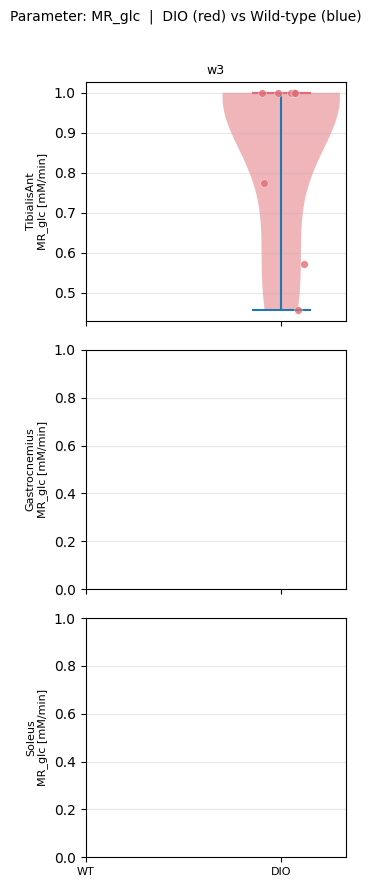

In [ ]:
# Cell 10 — Group Comparison: Box/Violin Plots
#
# Flatten all per-voxel results into a DataFrame, then plot
# {MR_glc, V_TCA, V_out, V_LK, T_max, V_x} grouped by (tissue × group × week).
# Mann-Whitney U test between DIO ('dia') and wild-type ('norm') per tissue/week.

# Build flat DataFrame of all per-voxel results
rows = []
for res in all_results:
    for vr in res['voxels']:
        rows.append(dict(
            mouseID = res['mouseID'],
            week    = res['week'],
            tissue  = res['tissue'],
            group   = res['group'],
            T_max   = res['T_max'],
            V_x     = res['V_x'],
            MR_glc  = vr['MR_glc'],
            V_TCA   = vr['V_TCA'],
            V_out   = vr['V_out'],
            V_LK    = get_voxel_param(vr, 'V_LK'),
            r2_glc  = vr['r2_glc'],
            r2_lac  = vr['r2_lac'],
            r2_glx  = vr['r2_glx'],
            r2_mean = vr['r2_mean'],
        ))

df_results = pd.DataFrame(rows)
print(f'Result table: {len(df_results)} voxels across {len(all_results)} samples')
if len(df_results) > 0:
    print(df_results[['tissue', 'group', 'week', 'MR_glc', 'V_TCA', 'V_out', 'V_LK', 'r2_mean']]
          .describe(include='all').round(3))


def plot_group_comparison(df, param, tissue_list=TISSUES, save_dir=plots_dir, show=False):
    """
    Violin + scatter plot of `param` per (tissue × group × week).
    Annotates statistically significant DIO vs. WT differences (Mann-Whitney U).
    """
    weeks_present = sorted(df['week'].unique(),
                            key=lambda w: WEEKS.index(w) if w in WEEKS else 99)
    n_weeks   = len(weeks_present)
    n_tissues = len(tissue_list)

    fig, axes = plt.subplots(
        n_tissues, n_weeks,
        figsize=(3.5 * n_weeks, 3 * n_tissues),
        sharex='col', sharey='row'
    )
    if n_tissues == 1:
        axes = axes[np.newaxis, :]
    if n_weeks == 1:
        axes = axes[:, np.newaxis]

    group_colors = {'dia': '#E06C75', 'norm': '#61AFEF'}
    groups = ['norm', 'dia']  # WT first

    for ti, tissue in enumerate(tissue_list):
        for wi, wk in enumerate(weeks_present):
            ax = axes[ti, wi]
            sub = df[(df['tissue'] == tissue) & (df['week'] == wk)]

            for gi, grp in enumerate(groups):
                vals = sub[sub['group'] == grp][param].values
                if len(vals) == 0:
                    continue
                x_pos = gi
                # Violin
                if len(vals) >= 3:
                    parts = ax.violinplot(
                        vals, positions=[x_pos], widths=0.6,
                        showmeans=False, showmedians=True
                    )
                    for pc in parts['bodies']:
                        pc.set_facecolor(group_colors[grp])
                        pc.set_alpha(0.5)
                    parts['cmedians'].set_color(group_colors[grp])
                # Individual dots jittered
                jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(vals))
                ax.scatter(
                    np.full(len(vals), x_pos) + jitter, vals,
                    color=group_colors[grp], s=30, zorder=4, alpha=0.8,
                    edgecolors='white', linewidths=0.3
                )

            # Mann-Whitney U significance annotation
            dia_vals  = sub[sub['group'] == 'dia'][param].values
            norm_vals = sub[sub['group'] == 'norm'][param].values
            if len(dia_vals) >= 2 and len(norm_vals) >= 2:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    _, pval = mannwhitneyu(dia_vals, norm_vals, alternative='two-sided')
                sig = '***' if pval < 0.001 else ('**' if pval < 0.01
                                                   else ('*' if pval < 0.05 else 'ns'))
                ax.text(0.5, 0.98, sig, ha='center', va='top',
                        transform=ax.transAxes, fontsize=10, color='black')

            ax.set_xticks([0, 1])
            ax.set_xticklabels(['WT', 'DIO'], fontsize=8)
            if wi == 0:
                ax.set_ylabel(f'{tissue}\n{param} [mM/min]', fontsize=8)
            if ti == 0:
                ax.set_title(wk, fontsize=9)
            ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(f'Parameter: {param}  |  DIO (red) vs Wild-type (blue)', fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fname = save_dir / f'group_comparison_{param}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


if len(df_results) > 0:
    print('Generating group comparison plots...')
    for param in ('MR_glc', 'V_TCA', 'V_out', 'V_LK', 'T_max', 'V_x'):
        plot_group_comparison(df_results, param, save_dir=plots_dir, show=False)
    print(f'Time-course and group comparison plots saved to {plots_dir}/')

    # Show one
    plot_group_comparison(df_results, 'MR_glc', save_dir=plots_dir, show=True)
else:
    print('No results available yet. Run Cell 7 first.')
